In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
cpu_df = pd.read_csv(
    "../data/Processed/cpu_baseline.csv"
)

cpu_df["ts"] = pd.to_datetime(
    cpu_df["ts"],
    format="mixed",
    utc=True
)

In [3]:
cpu_df = cpu_df.sort_values(
    ["hostName", "ts"]
).reset_index(drop=True)

In [4]:
# Rolling statistics per server
cpu_df["rolling_mean"] = (
    cpu_df
    .groupby("hostName")
    ["cpu_usage_pct"]
    .transform(
        lambda x: x.rolling(
            12,
            min_periods=1
        ).mean()
    )
)
cpu_df["rolling_std"] = (
    cpu_df
    .groupby("hostName")
    ["cpu_usage_pct"]
    .transform(
        lambda x: x.rolling(
            12,
            min_periods=1
        ).std()
    )
)

In [5]:
# Upper control limit
cpu_df["upper_limit"] = (
    cpu_df["rolling_mean"] + 3 * cpu_df["rolling_std"]
)

In [6]:
# Flag anomalies
cpu_df["anomaly"] = (
    cpu_df["cpu_usage_pct"]
    >
    cpu_df["upper_limit"]
)
# check
cpu_df["anomaly"].value_counts()

anomaly
False    73749
True       503
Name: count, dtype: int64

In [7]:
# Absolute threshold anomaly detection

ABSOLUTE_THRESHOLD = 70

cpu_df["anomaly_abs"] = (
    cpu_df["cpu_usage_pct"]
    >= ABSOLUTE_THRESHOLD
)

print("Dynamic Threshold Anomalies:")
print(cpu_df["anomaly"].sum())

print("\nAbsolute Threshold Anomalies:")
print(cpu_df["anomaly_abs"].sum())

Dynamic Threshold Anomalies:
503

Absolute Threshold Anomalies:
48


In [9]:
# create absolute threshold dataset

anomalies = cpu_df[
    cpu_df["anomaly_abs"]
].copy()

# Sort
anomalies = anomalies.sort_values(
    ["hostName","ts"]
)

# Calculate gap
anomalies["gap"] = (
    anomalies
    .groupby("hostName")["ts"]
    .diff()
)

# Create new event if gap > 30 min
anomalies["new_event"] = (
    anomalies["gap"]
    > pd.Timedelta(minutes=30)
)

# Assign event IDs
anomalies["event_id"] = (
    anomalies["new_event"]
    .cumsum()
)

In [11]:
# Event Summary table
event_summary = (
    anomalies
    .groupby(
        ["hostName","event_id"]
    )
    .agg(
        start_time=("ts","min"),
        end_time=("ts","max"),
        peak_cpu=("cpu_usage_pct","max"),
        samples=("cpu_usage_pct","count")
    )
    .reset_index()
)
event_summary

,hostName,event_id,start_time,end_time,peak_cpu,samples
0,10.10.10.150,0,2026-04-14 09:43:21.766000+00:00,2026-04-14 09:43:21.766000+00:00,88.0,1
1,10.10.10.150,1,2026-04-14 11:08:21.525000+00:00,2026-04-14 11:08:21.525000+00:00,76.0,1
2,10.10.10.150,2,2026-04-15 05:03:14.216000+00:00,2026-04-15 05:03:14.216000+00:00,77.0,1
3,10.10.10.150,3,2026-04-15 05:58:27.662000+00:00,2026-04-15 06:33:21.640000+00:00,86.0,4
4,10.10.10.150,4,2026-04-15 09:43:21.580000+00:00,2026-04-15 09:43:21.580000+00:00,70.0,1
5,10.10.10.150,5,2026-04-24 09:13:35.967000+00:00,2026-04-24 09:23:15.638000+00:00,80.0,3
6,10.10.10.150,6,2026-04-25 04:43:14.994000+00:00,2026-04-25 04:58:14.932000+00:00,100.0,3
7,10.10.10.150,7,2026-04-27 05:28:25.450000+00:00,2026-04-27 05:33:29.438000+00:00,93.0,2
8,10.10.10.150,8,2026-04-27 06:13:23.467000+00:00,2026-04-27 06:13:23.467000+00:00,87.0,1
9,10.10.10.150,9,2026-04-27 06:58:15.772000+00:00,2026-04-27 07:28:15.823000+00:00,91.0,5


In [13]:
TOP_EVENTS = 10

top_events = (
    event_summary
    .sort_values(
        "peak_cpu",
        ascending=False
    )
    .head(TOP_EVENTS)
)

top_events

,hostName,event_id,start_time,end_time,peak_cpu,samples
6,10.10.10.150,6,2026-04-25 04:43:14.994000+00:00,2026-04-25 04:58:14.932000+00:00,100.0,3
18,10.10.10.65,17,2026-04-25 04:43:14.994000+00:00,2026-04-25 04:58:14.932000+00:00,100.0,3
19,10.10.10.65,18,2026-04-27 05:28:25.450000+00:00,2026-04-27 05:33:29.438000+00:00,93.0,2
7,10.10.10.150,7,2026-04-27 05:28:25.450000+00:00,2026-04-27 05:33:29.438000+00:00,93.0,2
21,10.10.10.65,20,2026-04-27 06:58:15.772000+00:00,2026-04-27 07:28:15.823000+00:00,91.0,5
9,10.10.10.150,9,2026-04-27 06:58:15.772000+00:00,2026-04-27 07:28:15.823000+00:00,91.0,5
0,10.10.10.150,0,2026-04-14 09:43:21.766000+00:00,2026-04-14 09:43:21.766000+00:00,88.0,1
23,10.10.10.65,22,2026-04-28 07:28:15.335000+00:00,2026-04-28 07:28:15.335000+00:00,88.0,1
12,10.10.10.65,11,2026-04-14 09:43:21.766000+00:00,2026-04-14 09:43:21.766000+00:00,88.0,1
11,10.10.10.150,11,2026-04-28 07:28:15.335000+00:00,2026-04-28 07:28:15.335000+00:00,88.0,1


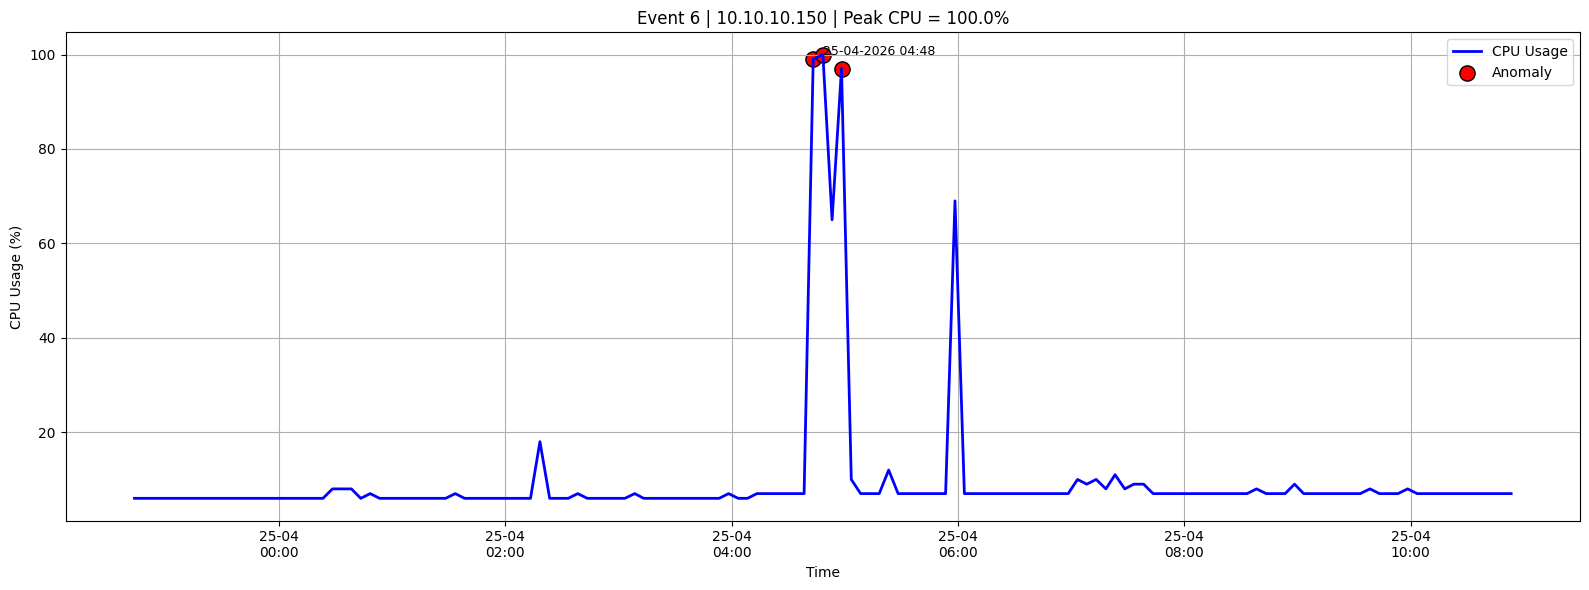

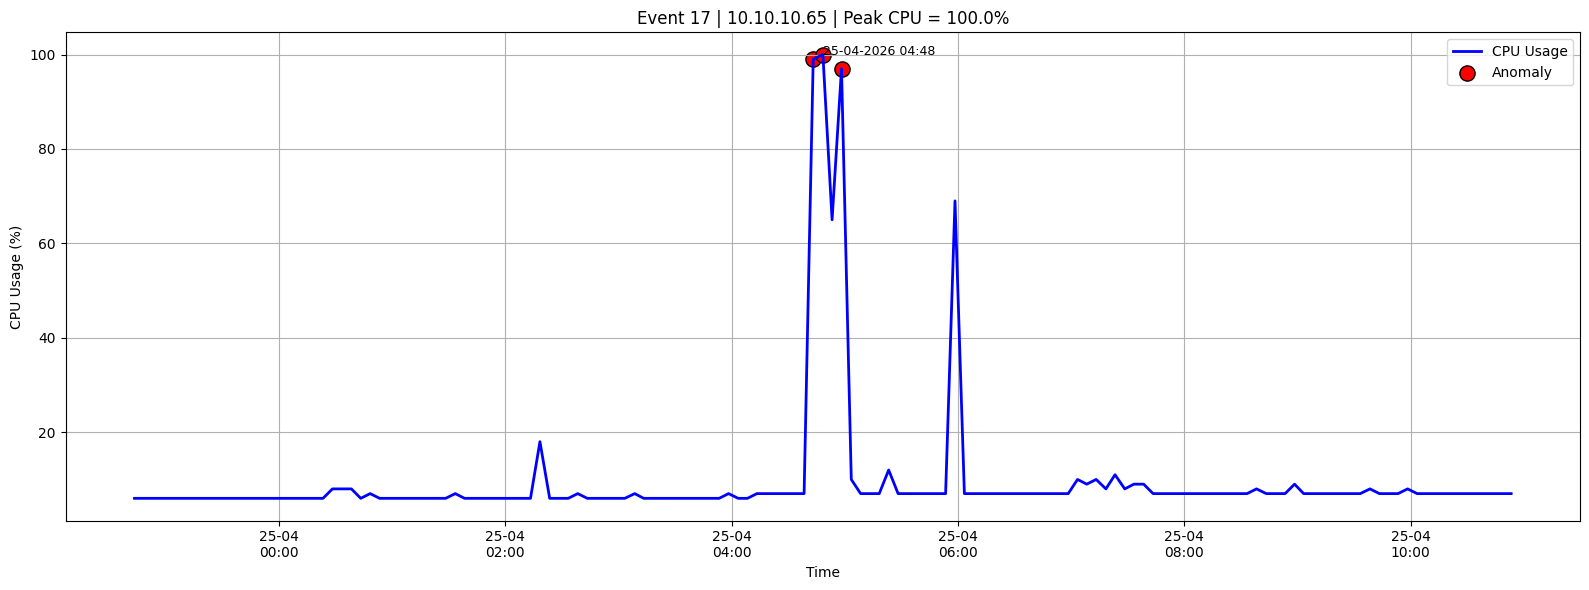

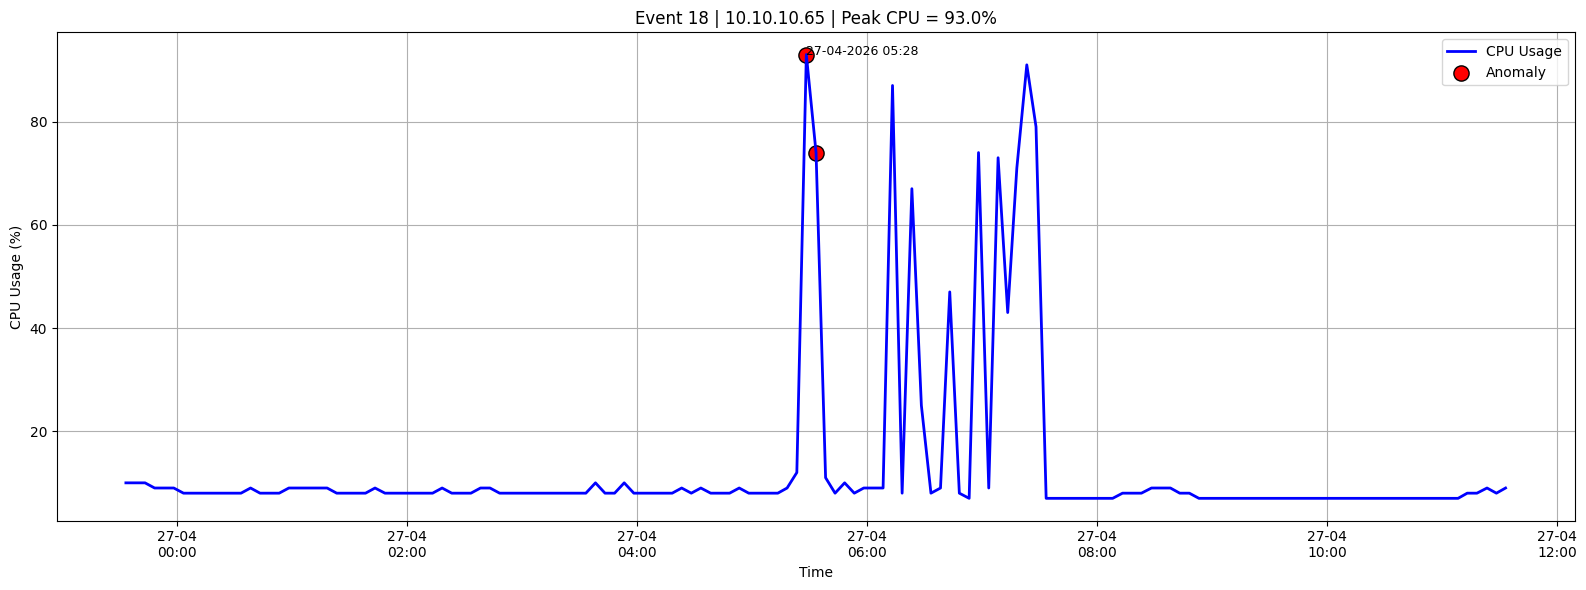

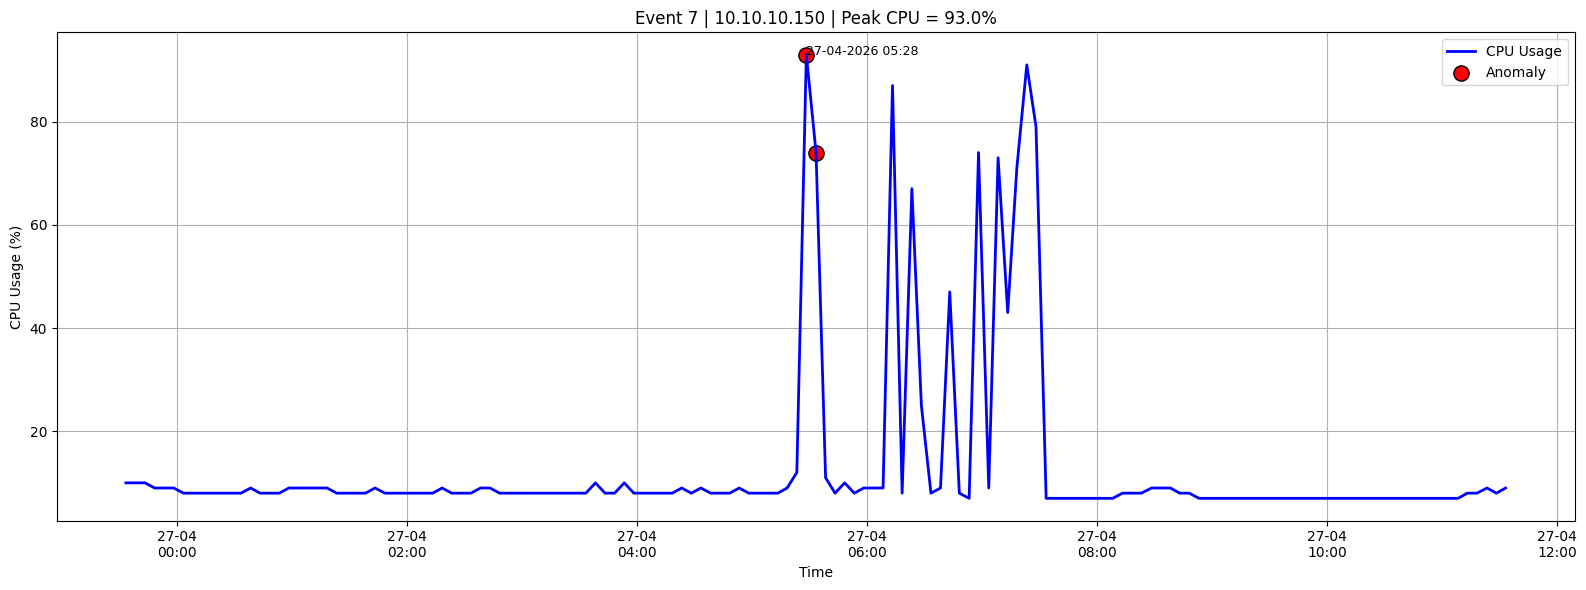

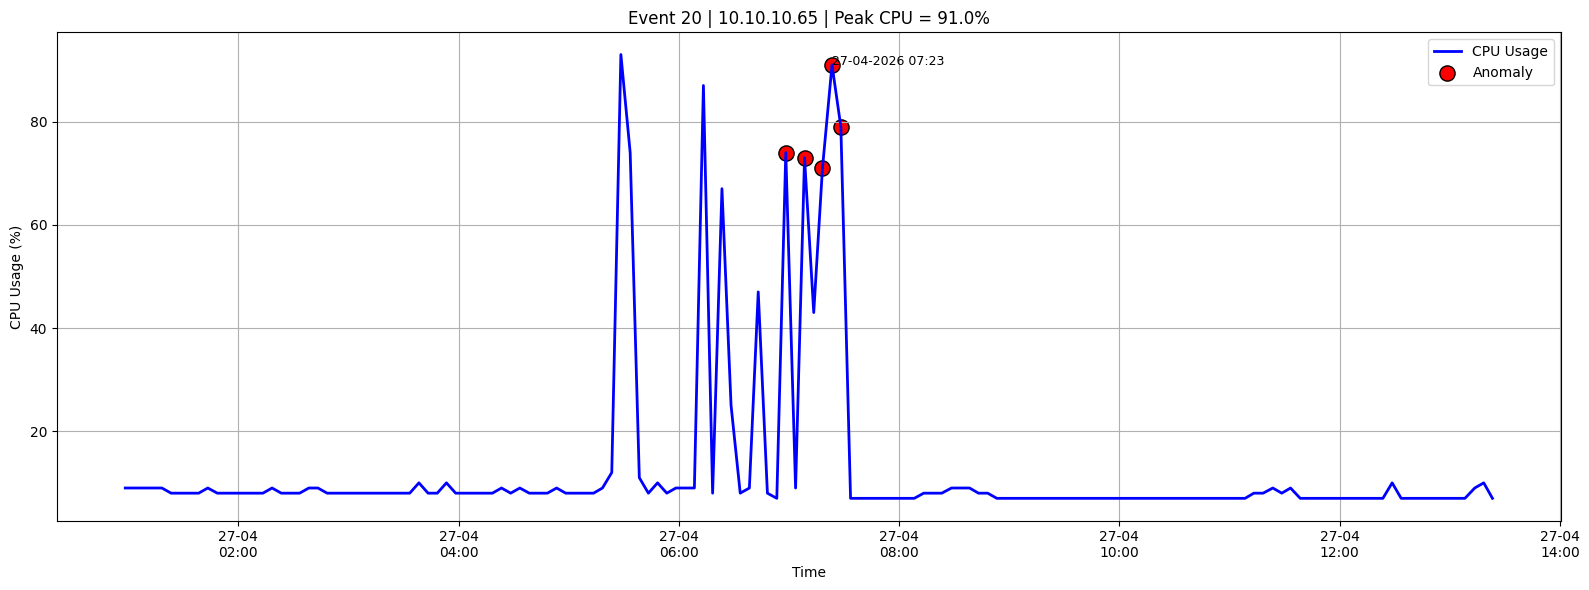

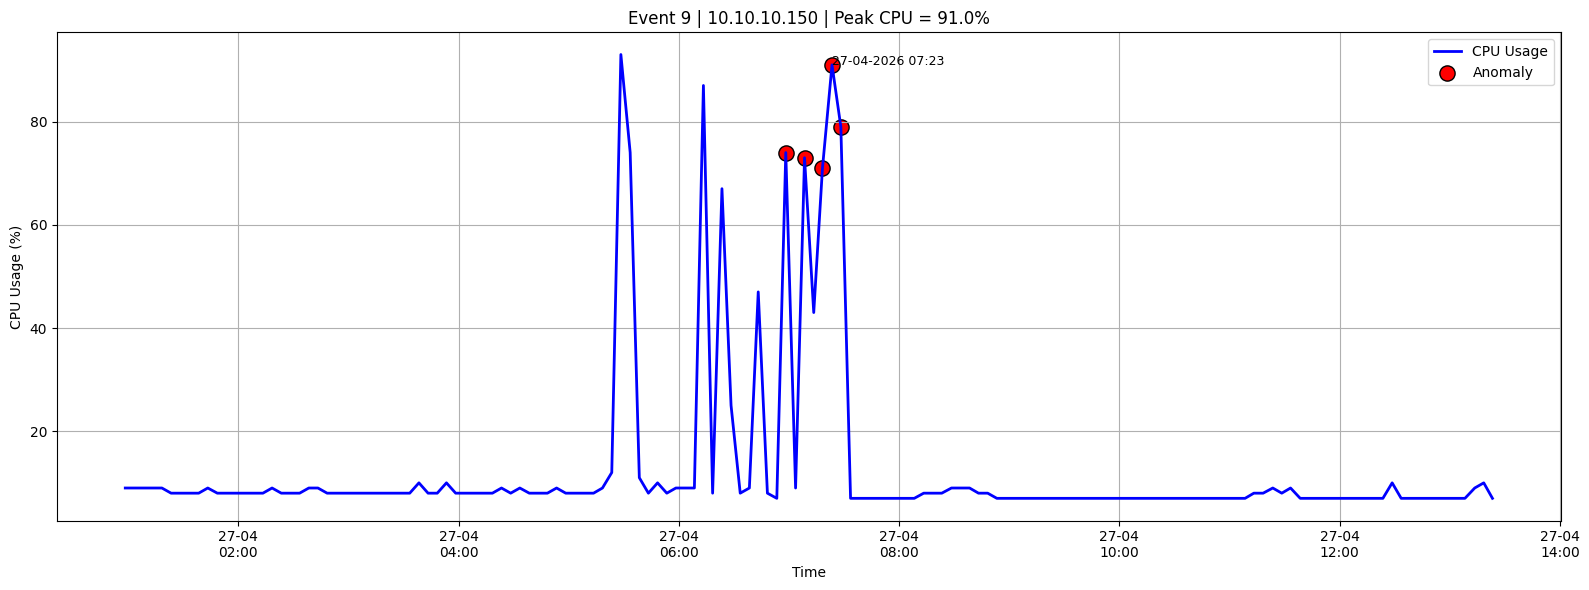

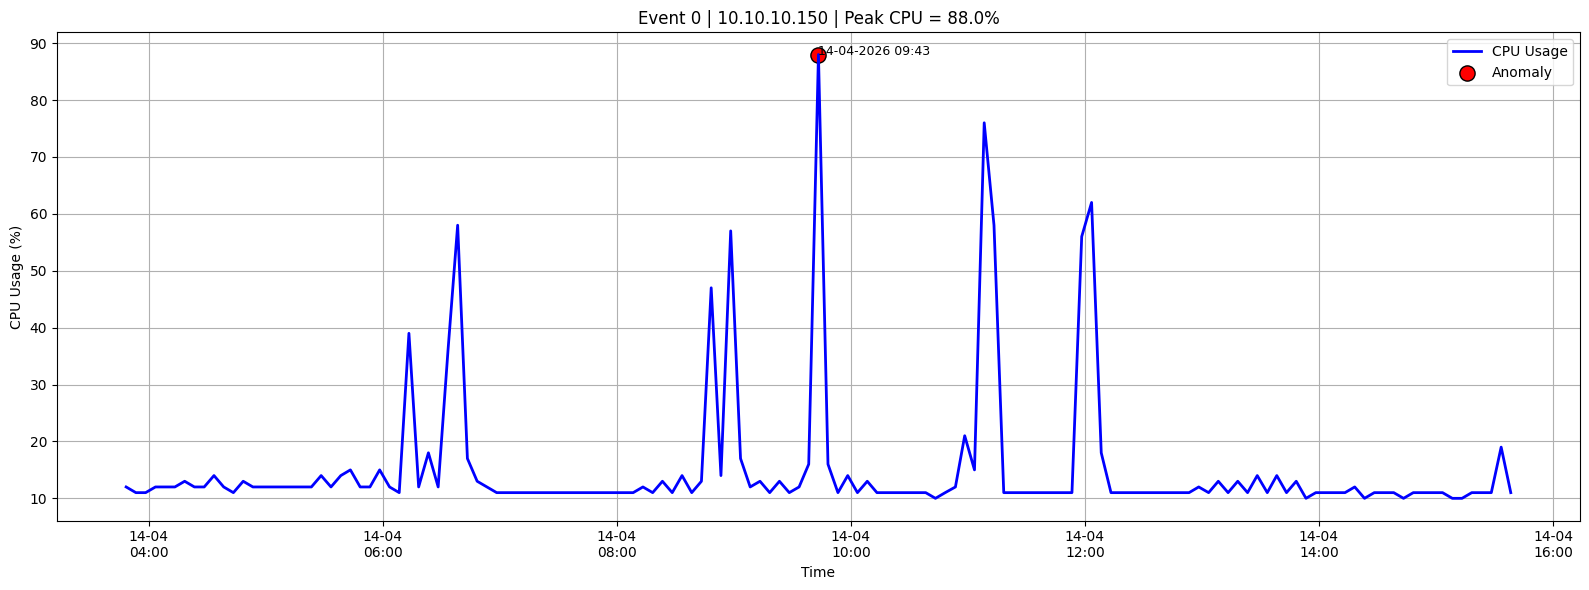

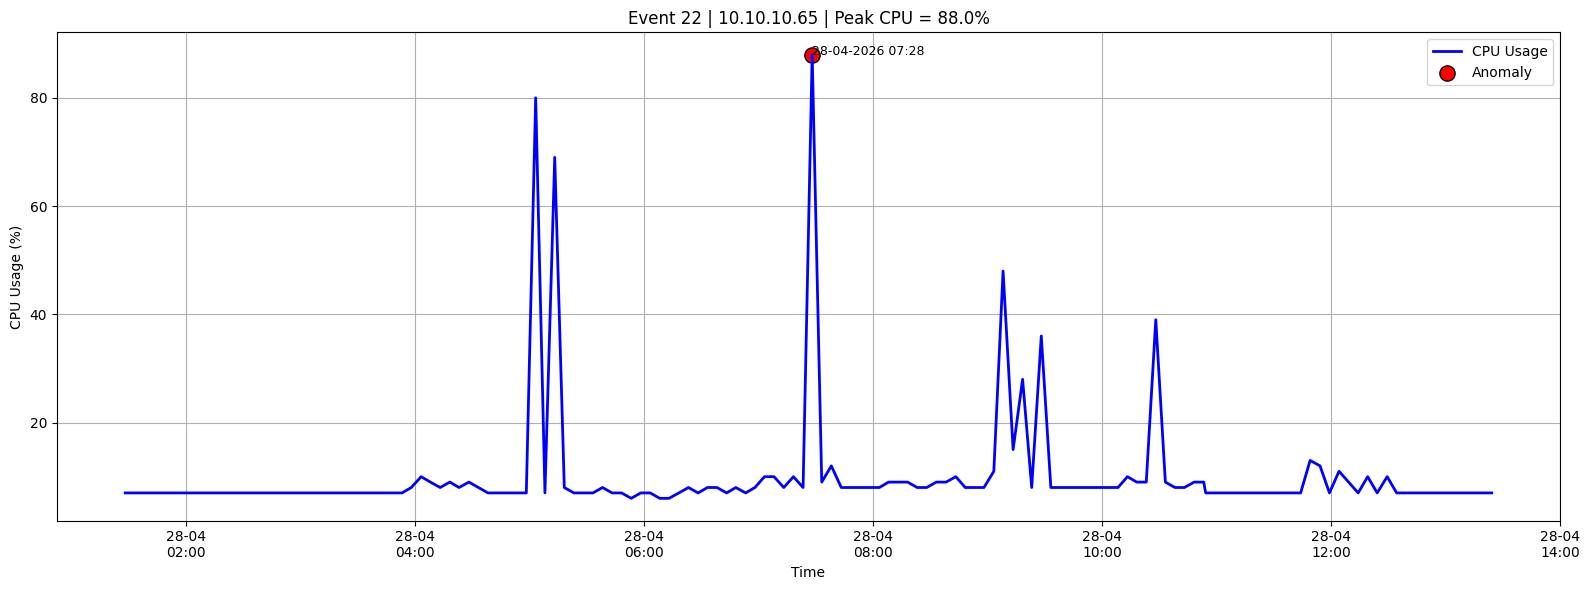

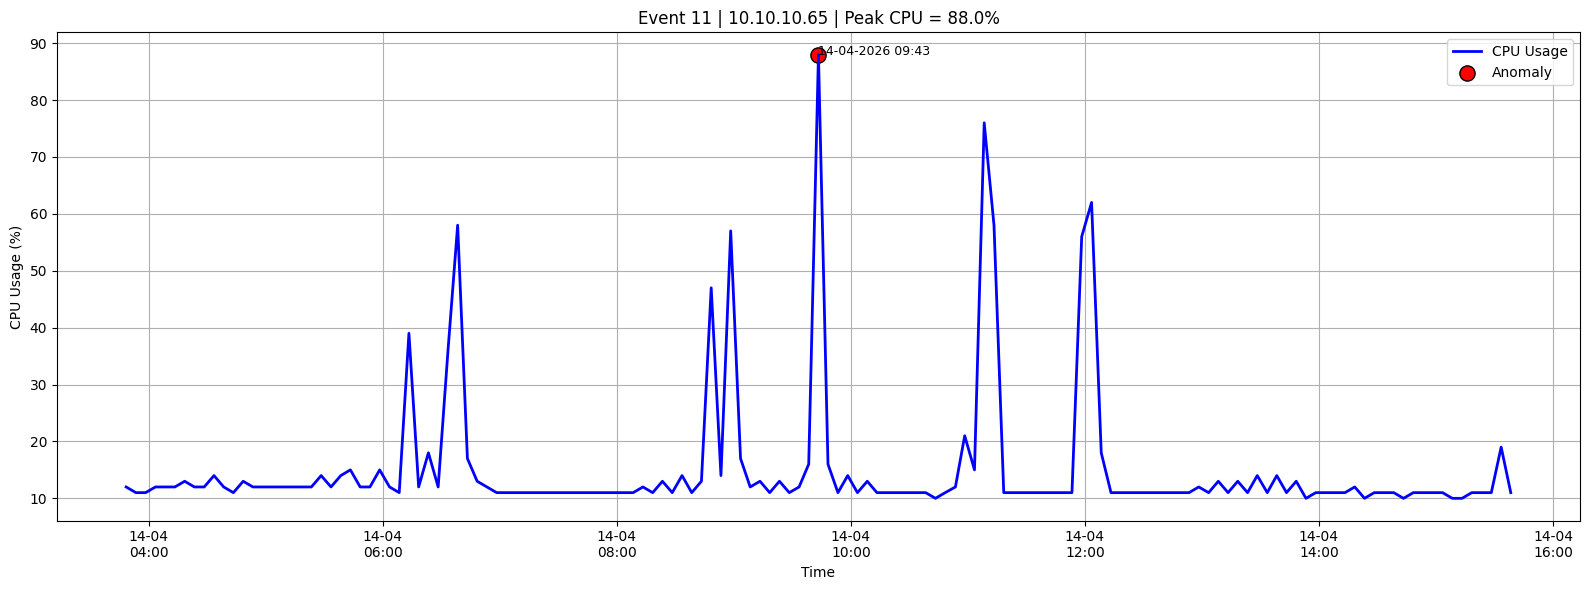

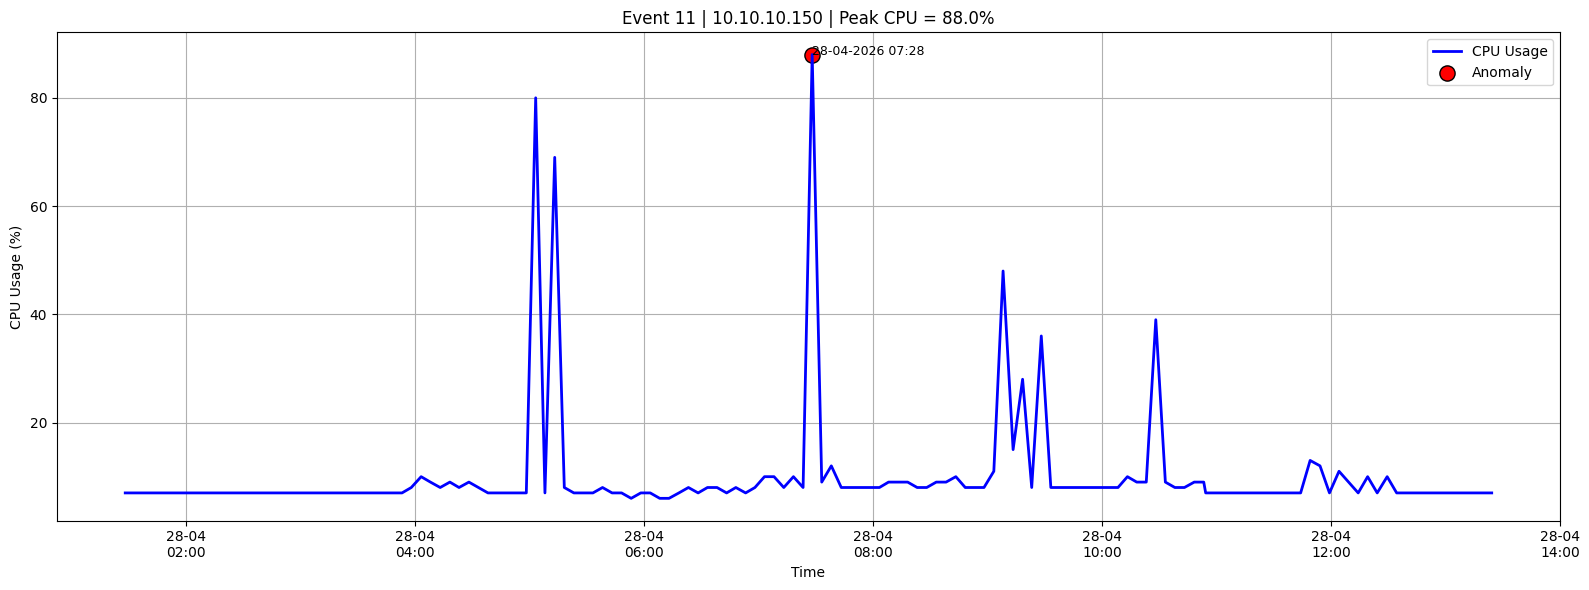

In [14]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

for _, event in top_events.iterrows():

    host = event["hostName"]

    start_time = event["start_time"]
    end_time = event["end_time"]

    # 6 hours before and after

    window_start = (
        start_time
        - pd.Timedelta(hours=6)
    )

    window_end = (
        end_time
        + pd.Timedelta(hours=6)
    )

    plot_df = cpu_df[
        (cpu_df["hostName"] == host)
        &
        (cpu_df["ts"] >= window_start)
        &
        (cpu_df["ts"] <= window_end)
    ]

    anomaly_points = anomalies[
        (anomalies["hostName"] == host)
        &
        (anomalies["event_id"] == event["event_id"])
    ]

    plt.figure(figsize=(16,6))

    plt.plot(
        plot_df["ts"],
        plot_df["cpu_usage_pct"],
        linewidth=2,
        color="blue",
        label="CPU Usage"
    )

    plt.scatter(
        anomaly_points["ts"],
        anomaly_points["cpu_usage_pct"],
        color="red",
        s=120,
        edgecolors="black",
        label="Anomaly"
    )

    # label only peak anomaly

    peak_row = anomaly_points.loc[
        anomaly_points["cpu_usage_pct"].idxmax()
    ]

    plt.annotate(
        peak_row["ts"].strftime(
            "%d-%m-%Y %H:%M"
        ),
        (
            peak_row["ts"],
            peak_row["cpu_usage_pct"]
        ),
        fontsize=9
    )

    plt.title(
        f"Event {event['event_id']} | "
        f"{host} | Peak CPU = {event['peak_cpu']}%"
    )

    plt.xlabel("Time")
    plt.ylabel("CPU Usage (%)")

    ax = plt.gca()

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter(
            "%d-%m\n%H:%M"
        )
    )

    plt.grid(True)

    plt.legend()

    plt.tight_layout()

    plt.show()

In [12]:
# Rank events
event_summary = (
    event_summary
    .sort_values(
        "peak_cpu",
        ascending=False
    )
)

In [8]:
# extract anomalies
anomalies = cpu_df[
    cpu_df["anomaly"]
].copy()

anomalies.shape

# view exact events
anomalies[
    [
        "ts",
        "hostName",
        "cpu_usage_pct",
        "rolling_mean",
        "upper_limit"
    ]
].head(50)

,ts,hostName,cpu_usage_pct,rolling_mean,upper_limit
499,2026-04-03 05:21:08.696000+00:00,10.10.10.150,32.0,17.000000,31.301939
694,2026-04-03 11:51:08.733000+00:00,10.10.10.150,21.0,15.916667,20.946125
1795,2026-04-05 00:33:19.755000+00:00,10.10.10.150,17.0,16.083333,16.949359
2538,2026-04-06 01:19:19.481000+00:00,10.10.10.150,16.0,15.083333,15.949359
5646,2026-04-10 08:55:19.616000+00:00,10.10.10.150,26.0,11.833333,25.361083
5684,2026-04-10 10:11:21.652000+00:00,10.10.10.150,22.0,14.250000,21.722678
6144,2026-04-11 01:31:19.486000+00:00,10.10.10.150,11.0,10.083333,10.949359
6219,2026-04-11 04:01:19.621000+00:00,10.10.10.150,11.0,10.083333,10.949359
6284,2026-04-11 06:11:25.544000+00:00,10.10.10.150,19.0,11.166667,18.716501
6328,2026-04-11 07:39:21.538000+00:00,10.10.10.150,18.0,11.333333,17.771854


In [15]:
# Plot per server
host = "10.10.10.65"
server_df = cpu_df[
    cpu_df["hostName"] == host
].copy()

server_df["month"] = (
    server_df["ts"]
    .dt.strftime("%Y-%m")
)

print(
    server_df["month"].unique()
)

month_df = server_df[
    server_df["month"] == "2026-04"
]

# every 10th sample
plot_df = month_df.iloc[::10]

month_anom = month_df[
    month_df["anomaly"]
]

['2026-04' '2026-05' '2026-06']


In [19]:
host = "10.10.10.65"
server_df = cpu_df[
    cpu_df["hostName"] == host
].copy()

server_df["month"] = (
    server_df["ts"]
    .dt.strftime("%Y-%m")
)

print(
    server_df["month"].unique()
)

month_df = server_df[
    server_df["month"] == "2026-04"
]

# every 10th sample
plot_df = month_df.iloc[::10]

month_anom = month_df[
    month_df["anomaly_abs"]
]

['2026-04' '2026-05' '2026-06']


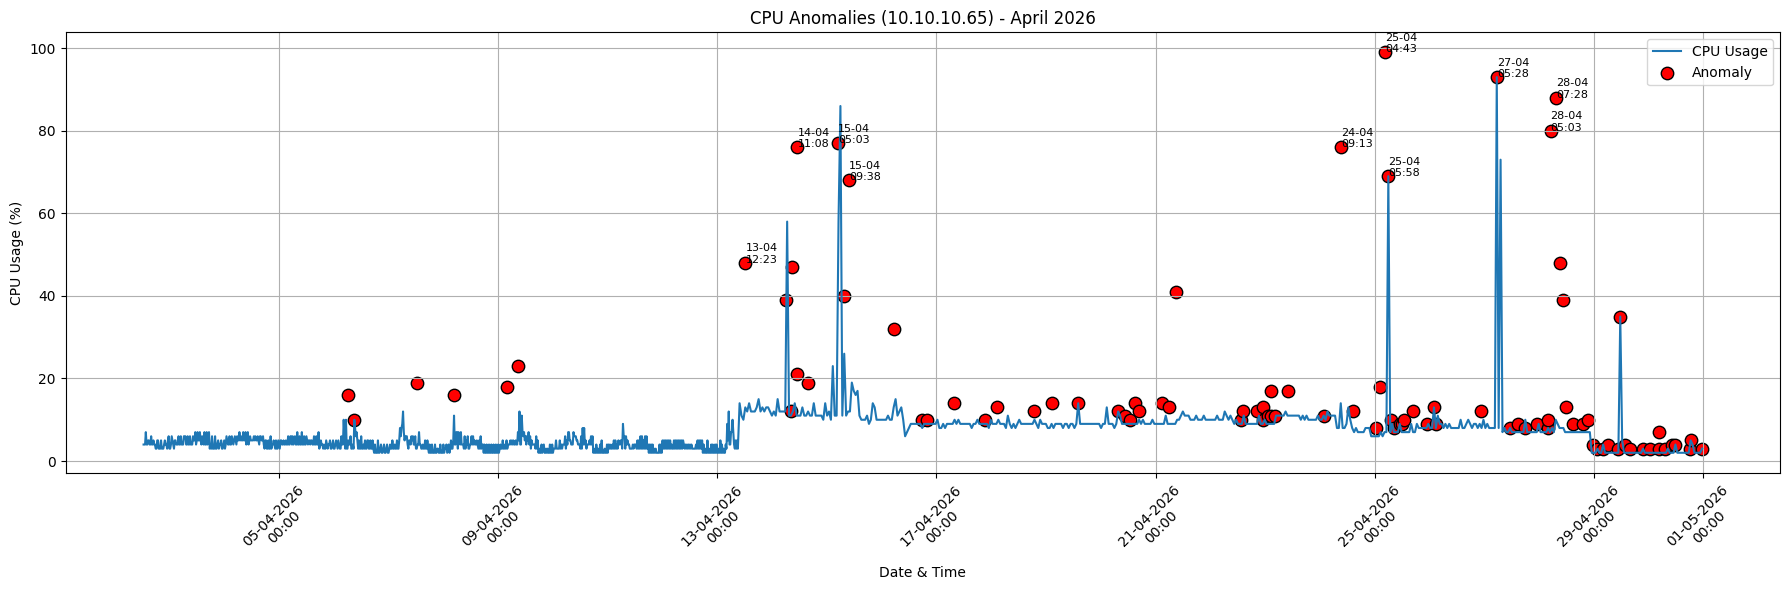

In [16]:
# Time-series plot
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(18,6))

plt.plot(
    plot_df["ts"],
    plot_df["cpu_usage_pct"],
    linewidth=1.5,
    label="CPU Usage"
)

plt.scatter(
    month_anom["ts"],
    month_anom["cpu_usage_pct"],
    color="red",
    s=80,
    edgecolors="black",
    label="Anomaly"
)

# Label only top 10
top_month_anom = (
    month_anom
    .sort_values(
        "cpu_usage_pct",
        ascending=False
    )
    .head(10)
)

for _, row in top_month_anom.iterrows():

    plt.annotate(
        row["ts"].strftime(
            "%d-%m\n%H:%M"
        ),
        (
            row["ts"],
            row["cpu_usage_pct"]
        ),
        fontsize=8
    )

# time axis
ax = plt.gca()

ax.xaxis.set_major_formatter(
    mdates.DateFormatter(
        "%d-%m-%Y\n%H:%M"
    )
)

plt.xticks(rotation=45)

# finish
plt.title(
    f"CPU Anomalies ({host}) - April 2026"
)

plt.xlabel("Date & Time")

plt.ylabel("CPU Usage (%)")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.show()

In [13]:
# Top anomalies table
top_anomalies = anomalies.sort_values(
    "cpu_usage_pct",
    ascending=False
)

top_anomalies[
    [
        "ts",
        "hostName",
        "cpu_usage_pct",
        "upper_limit"
    ]
].head(20)

,ts,hostName,cpu_usage_pct,upper_limit
60717,2026-04-25 04:43:14.994000+00:00,10.10.10.65,99.0,94.335606
11215,2026-04-25 04:43:14.994000+00:00,10.10.10.150,99.0,94.335606
11800,2026-04-27 05:28:25.450000+00:00,10.10.10.150,93.0,88.809118
61302,2026-04-27 05:28:25.450000+00:00,10.10.10.65,93.0,88.809118
61614,2026-04-28 07:28:15.335000+00:00,10.10.10.65,88.0,84.041490
12112,2026-04-28 07:28:15.335000+00:00,10.10.10.150,88.0,84.041490
12083,2026-04-28 05:03:24.429000+00:00,10.10.10.150,80.0,76.394576
61585,2026-04-28 05:03:24.429000+00:00,10.10.10.65,80.0,76.394576
8339,2026-04-15 05:03:14.216000+00:00,10.10.10.150,77.0,73.659415
57841,2026-04-15 05:03:14.216000+00:00,10.10.10.65,77.0,73.659415


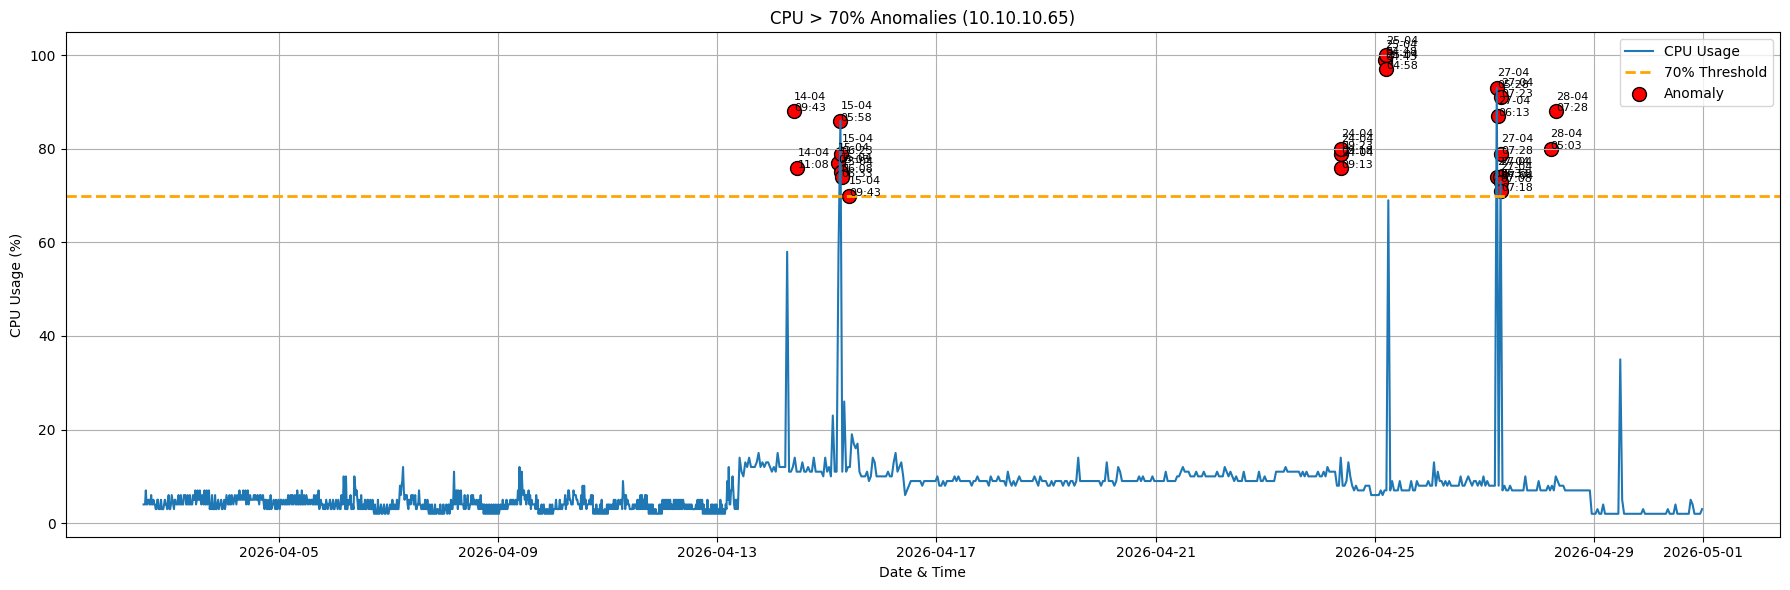

In [20]:
plt.figure(figsize=(18,6))

plt.plot(
    plot_df["ts"],
    plot_df["cpu_usage_pct"],
    linewidth=1.5,
    label="CPU Usage"
)

plt.axhline(
    y=70,
    linestyle="--",
    linewidth=2,
    color="orange",
    label="70% Threshold"
)

plt.scatter(
    month_anom["ts"],
    month_anom["cpu_usage_pct"],
    color="red",
    s=100,
    edgecolors="black",
    label="Anomaly"
)

for _, row in month_anom.iterrows():

    plt.annotate(
        row["ts"].strftime("%d-%m\n%H:%M"),
        (
            row["ts"],
            row["cpu_usage_pct"]
        ),
        fontsize=8
    )

plt.title(
    f"CPU > 70% Anomalies ({host})"
)

plt.xlabel("Date & Time")

plt.ylabel("CPU Usage (%)")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()